[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/quantitative-research-methods/blob/main/Lab_Notebooks/chapter_01_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 1 — Introduction
## Lab: getting comfortable with the tools and the data

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal of this lab.** Spin up the Python tooling, load the three motivating data sets (Wage, Smarket, NCI60), and reproduce the exploratory visualisations from the chapter.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/quantitative-research-methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. The Wage data
Survey of 3,000 men working in the central Atlantic region of the U.S. Continuous response `wage` $\Rightarrow$ regression problem.


In [2]:
Wage = load('Wage')
print(Wage.shape)
Wage.head()


(3000, 11)


,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
Wage.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,3000.0,NaN,NaN,NaN,2005.791,2.026167,2003.0,2004.0,2006.0,2008.0,2009.0
age,3000.0,NaN,NaN,NaN,42.414667,11.542406,18.0,33.75,42.0,51.0,80.0
maritl,3000,5,2. Married,2074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,3000,4,1. White,2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,3000,5,2. HS Grad,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,3000,1,2. Middle Atlantic,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jobclass,3000,2,1. Industrial,1544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health,3000,2,2. >=Very Good,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health_ins,3000,2,1. Yes,2083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
logwage,3000.0,NaN,NaN,NaN,4.653905,0.351753,3.0,4.447158,4.653213,4.857332,5.763128


### Wage vs. Age, Year, Education (Figure 1.1)


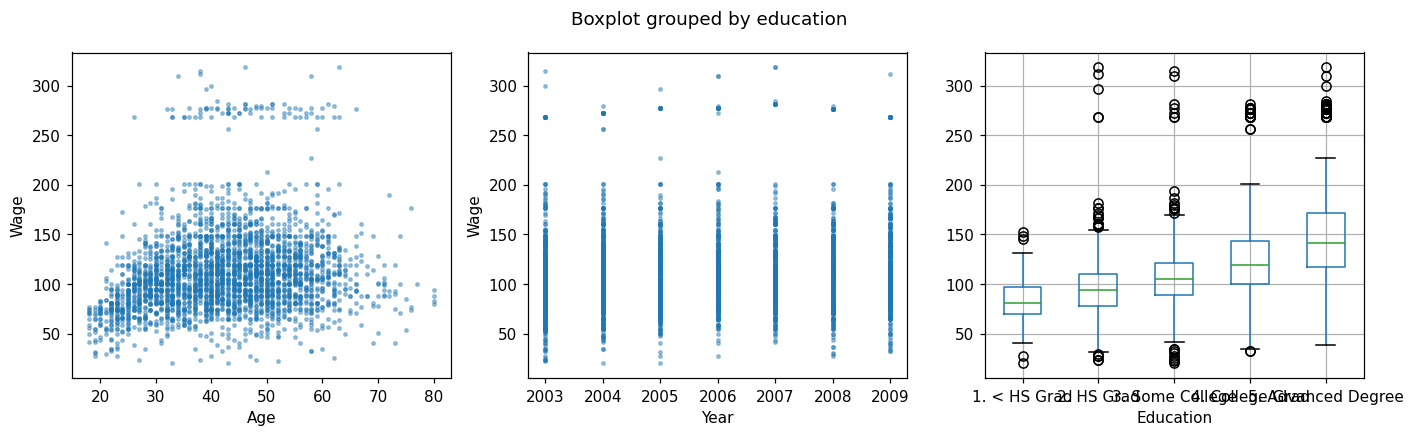

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(Wage['age'], Wage['wage'], s=5, alpha=0.4)
axes[0].set(xlabel='Age', ylabel='Wage')
axes[1].scatter(Wage['year'], Wage['wage'], s=5, alpha=0.4)
axes[1].set(xlabel='Year', ylabel='Wage')
Wage.boxplot(column='wage', by='education', ax=axes[2])
axes[2].set_title(''); axes[2].set_xlabel('Education')
plt.tight_layout(); plt.show()


### Discussion
* `wage` increases with `age` then plateaus and slightly declines.
* `wage` rises gently with `year`.
* `wage` is sharply increasing in `education`.
* These suggest a **non-linear** dependence on age — a hint that polynomial or spline regression (Ch. 7) will help.


## 2. The Stock Market data
Daily S&P 500 returns from 2001–2005. Categorical response `Direction` $\Rightarrow$ classification problem.


In [5]:
Smarket = load('Smarket')
print(Smarket.shape)
Smarket.head()


(1250, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


### Lag boxplots by direction (Figure 1.2)


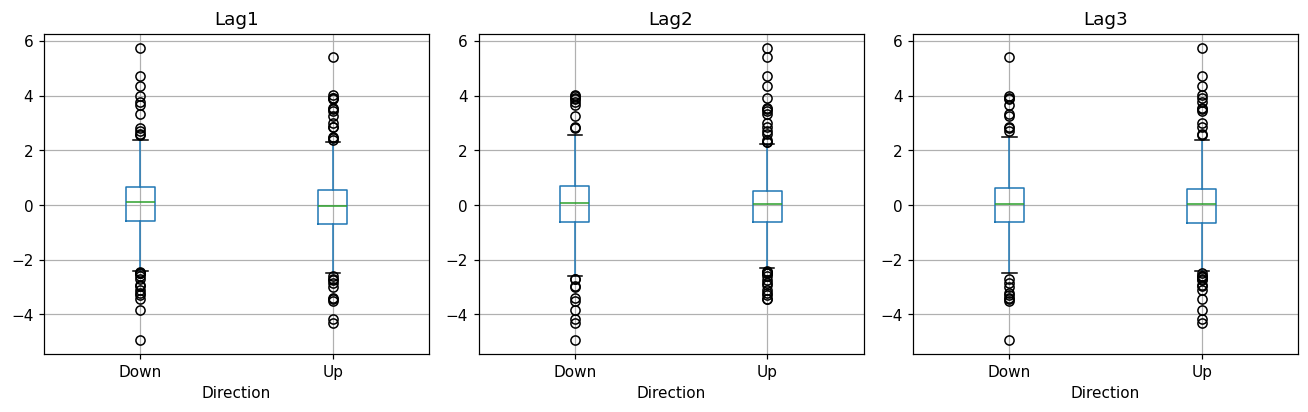

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, lag in zip(axes, ['Lag1', 'Lag2', 'Lag3']):
    Smarket.boxplot(column=lag, by='Direction', ax=ax)
    ax.set_title(lag); ax.set_xlabel('Direction')
plt.suptitle(''); plt.tight_layout(); plt.show()


Boxplots overlap heavily — past returns barely predict the next day's direction. Consistent with the efficient-markets view.


## 3. The NCI60 cancer cell lines
64 cell lines, 6 830 gene-expression measurements. No response — this is **unsupervised** territory.


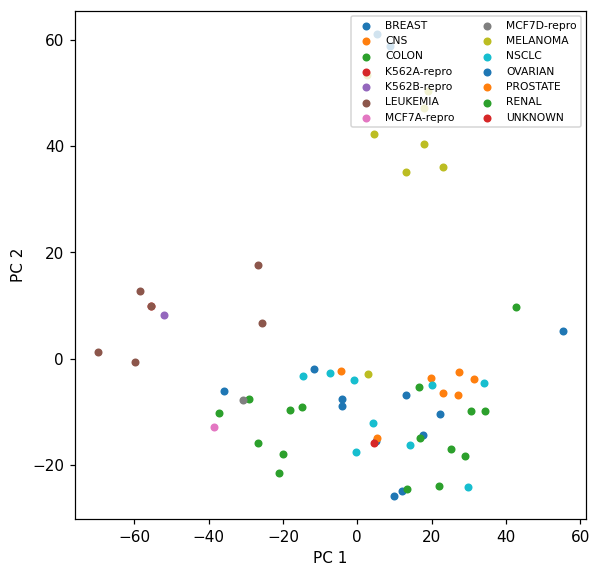

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

if HAVE_ISLP:
    nci = load_data('NCI60')
    X = nci['data']; labs = nci['labels'].squeeze()
else:
    print('NCI60 only ships with the ISLP package.')
    X = labs = None

if X is not None:
    Xs = StandardScaler().fit_transform(X)
    Z = PCA(n_components=2).fit_transform(Xs)
    fig, ax = plt.subplots(figsize=(6, 6))
    for k in np.unique(labs):
        m = labs == k
        ax.scatter(Z[m, 0], Z[m, 1], label=k, s=18)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    plt.show()


Cell lines of the same cancer type tend to cluster together — PCA recovered biologically meaningful structure without ever being told the labels.


## Lecture exercises — worked Python solutions

The chapter 1 slide deck contains no `[Python]`-tagged exercise (its exercises are tagged `[Concept]`, `[Math]`, and `[Integrative]`). This section therefore mirrors the deck's most **code-suitable** exercise — **Exercise 1.3 (Notation: $n$, $p$, and $\mathbf{X}$)**, tagged `[Math]` on the slides — adapted into a fully worked, runnable Python solution. Every quantity from the slide solution is recomputed and verified in code; the expected values appear as trailing comments.

### Exercise 1.3 — Notation: $n$, $p$, and $\mathbf{X}$ *(slide: Exercise 1.3 [Math], adapted to Python)*

For five patients we record `age` (years), `BMI`, and resting heart rate `HR`; the response is systolic blood pressure `SBP`.

| Patient | age | BMI | HR | SBP |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 45 | 24.0 | 70 | 128 |
| 2 | 60 | 29.5 | 82 | 145 |
| 3 | 52 | 26.1 | 75 | 138 |
| 4 | 38 | 22.3 | 68 | 120 |
| 5 | 71 | 31.0 | 90 | 158 |

1. State $n$ and $p$.
2. Give the dimensions of the design matrix $\mathbf{X}$ and the response vector $\mathbf{y}$.
3. Write the predictor vector $x_3$ and give the value $x_{2,3}$.
4. If an intercept column of ones is added, what are the dimensions of the model matrix?
5. Is this a regression or a classification problem?

In [8]:
# Exercise 1.3 — worked solution ----------------------------------------------
# The data are given in the exercise itself, so we build the table directly
# (no CSV / load() needed). Rows = observations (patients), columns = variables.
patients = pd.DataFrame(
    {'age': [45, 60, 52, 38, 71],
     'BMI': [24.0, 29.5, 26.1, 22.3, 31.0],
     'HR':  [70, 82, 75, 68, 90],
     'SBP': [128, 145, 138, 120, 158]},
    index=pd.RangeIndex(1, 6, name='patient'))

# (1) n and p. SBP is the RESPONSE we model, so it is never counted in p.
X = patients[['age', 'BMI', 'HR']].to_numpy()      # design matrix (predictors only)
y = patients['SBP'].to_numpy()                     # response vector
n, p = X.shape
print('n =', n, '  p =', p)                        # expected: n = 5   p = 3

# (2) dimensions of X and y
print('X:', X.shape, '  y:', y.shape)              # expected: X: (5, 3)   y: (5,)

# (3) x_3 = row 3 of X = all predictors of patient 3. NB: Python indexes rows
#     from 0, so slide row i is X[i - 1].
x_3 = X[3 - 1]
print('x_3  =', x_3)                               # expected: [52.  26.1 75. ]
#     x_{2,3}: FIRST index = row (observation), SECOND = column (predictor),
#     i.e. predictor 3 (HR) of patient 2 — not BMI of patient 3!
print('x_23 =', X[2 - 1, 3 - 1])                   # expected: 82.0

# (4) model matrix with an intercept column of ones prepended
X_tilde = np.column_stack([np.ones(n), X])
print('with intercept column:', X_tilde.shape)     # expected: (5, 4) = n x (p+1)

# (5) SBP is quantitative (mmHg, on a continuous scale) -> a REGRESSION problem
print('SBP dtype:', patients['SBP'].dtype, '-> quantitative -> regression')

n = 5   p = 3
X: (5, 3)   y: (5,)
x_3  = [52.  26.1 75. ]
x_23 = 82.0
with intercept column: (5, 4)
SBP dtype: int64 -> quantitative -> regression


## 4. Exercises
1. Reproduce the boxplots above for `Lag4` and `Lag5` of the Smarket data. Do you see any difference between the lags?
2. Compute the empirical correlation between `wage` and each numeric predictor in the Wage data set.
3. In NCI60, fit a 5-component PCA. What proportion of total variance do the first 5 components capture?
4. Pick any other ISLP data set (`Boston`, `Auto`, `Default`, `Hitters`, …), compute summary statistics, and plot the response against one continuous predictor.
